# Generate a white Gaussian noise signal. 

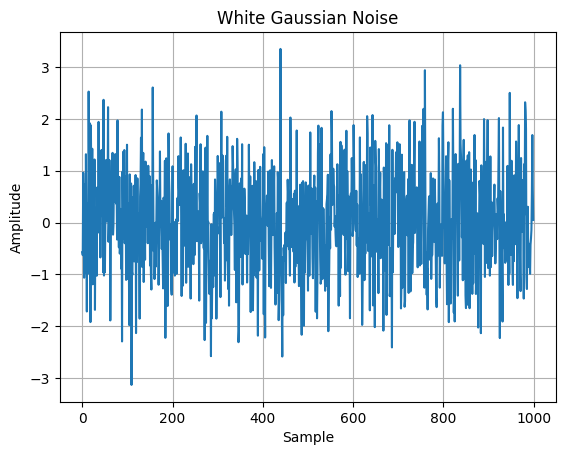

Estimated Mean: 0.0094
Estimated Variance: 0.9669


In [1]:
#1. White Gaussian Noise (WGN)}
#A zero-mean, normally distributed random signal with flat power spectral density.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

N = 1000
white_noise = np.random.normal(loc=0.0, scale=1.0, size=N)

# Statistical properties
mean = np.mean(white_noise)
variance = np.var(white_noise)

plt.plot(white_noise)
plt.title("White Gaussian Noise")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

print(f"Estimated Mean: {mean:.4f}")
print(f"Estimated Variance: {variance:.4f}")

# Fit AR(1), AR(2), and MA(1) models. 

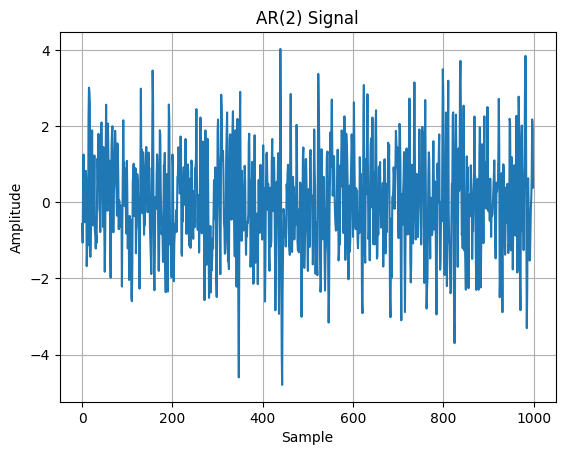

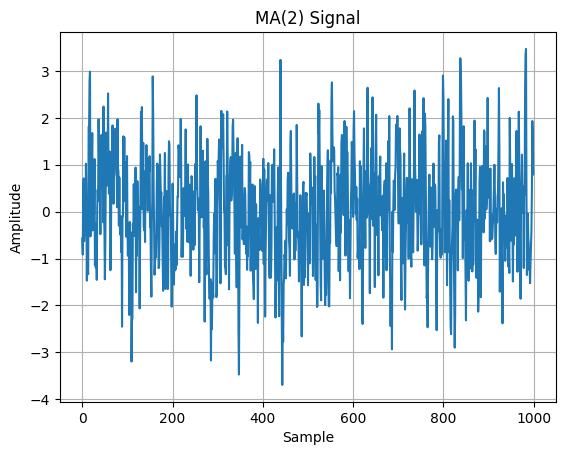

AR(1) summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1544.866
Date:                Wed, 20 May 2026   AIC                           3095.732
Time:                        20:54:51   BIC                           3110.456
Sample:                             0   HQIC                          3101.328
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0135      0.073      0.185      0.853      -0.130       0.157
ar.L1          0.5102      0.027     18.872      0.000       0.457       0.563
sigma2         1.2860      0.059     

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from statsmodels.tsa.arima.model import ARIMA

a = [1, -0.75, 0.5]  # AR coefficients
ar_signal = lfilter([1], a, white_noise)

plt.figure()
plt.plot(ar_signal)
plt.title("AR(2) Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

b = [1.0, 0.5, 0.25]  # MA coefficients
ma_signal = lfilter(b, [1], white_noise)

plt.figure()
plt.plot(ma_signal)
plt.title("MA(2) Signal")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# AR(1)
model_ar1 = ARIMA(ar_signal, order=(1, 0, 0)).fit()
print("AR(1) summary:")
print(model_ar1.summary())

# AR(2)
model_ar2 = ARIMA(ar_signal, order=(2, 0, 0)).fit()
print("\nAR(2) summary:")
print(model_ar2.summary())

# MA(1)
model_ma1 = ARIMA(ma_signal, order=(0, 0, 1)).fit()
print("\nMA(1) summary:")
print(model_ma1.summary())

# Compare AIC and residual variance.

In [6]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

model_ar1 = ARIMA(ar_signal, order=(1, 0, 0)).fit()
model_ar2 = ARIMA(ar_signal, order=(2, 0, 0)).fit()
model_ma1_ar = ARIMA(ar_signal, order=(0, 0, 1)).fit()

model_ar1_ma = ARIMA(ma_signal, order=(1, 0, 0)).fit()
model_ar2_ma = ARIMA(ma_signal, order=(2, 0, 0)).fit()
model_ma1 = ARIMA(ma_signal, order=(0, 0, 1)).fit()

def residual_variance(model):
    return np.var(model.resid)

print("=== AR SIGNAL ===")
print(f"AR(1): AIC={model_ar1.aic:.2f}, ResidVar={residual_variance(model_ar1):.4f}")
print(f"AR(2): AIC={model_ar2.aic:.2f}, ResidVar={residual_variance(model_ar2):.4f}")
print(f"MA(1): AIC={model_ma1_ar.aic:.2f}, ResidVar={residual_variance(model_ma1_ar):.4f}")

print("\n=== MA SIGNAL ===")
print(f"AR(1): AIC={model_ar1_ma.aic:.2f}, ResidVar={residual_variance(model_ar1_ma):.4f}")
print(f"AR(2): AIC={model_ar2_ma.aic:.2f}, ResidVar={residual_variance(model_ar2_ma):.4f}")
print(f"MA(1): AIC={model_ma1.aic:.2f}, ResidVar={residual_variance(model_ma1):.4f}")

=== AR SIGNAL ===
AR(1): AIC=3095.73, ResidVar=1.2861
AR(2): AIC=2812.50, ResidVar=0.9666
MA(1): AIC=2933.37, ResidVar=1.0932

=== MA SIGNAL ===
AR(1): AIC=2821.70, ResidVar=0.9779
AR(2): AIC=2820.45, ResidVar=0.9747
MA(1): AIC=2867.96, ResidVar=1.0243
